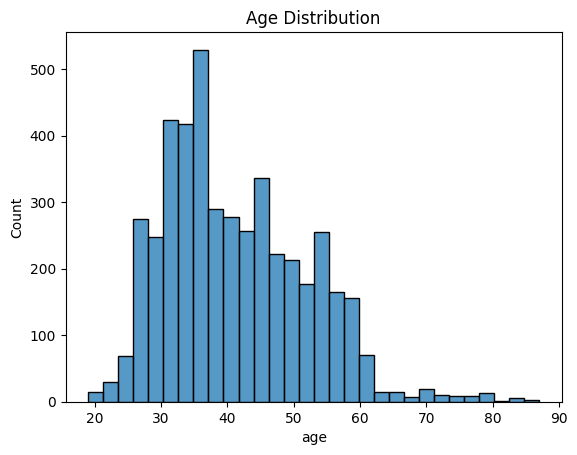

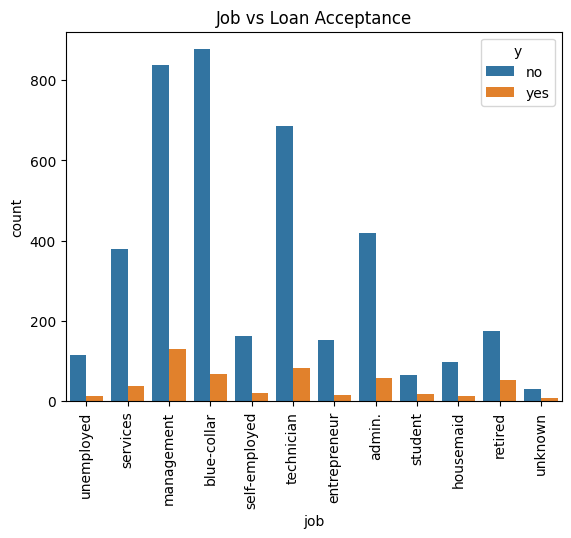

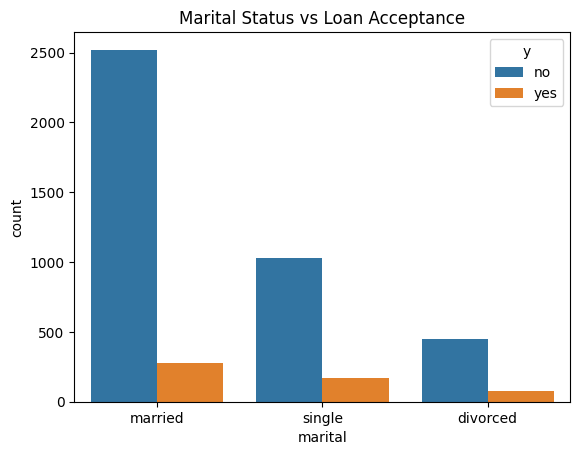

Accuracy: 0.8806629834254144
Confusion Matrix:
 [[748  59]
 [ 49  49]]


In [3]:
# ======================================
# Personal Loan Acceptance Prediction
# ======================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("bank.csv", sep=";")

# -----------------------------
# Basic Data Exploration
# -----------------------------

# Age Distribution
sns.histplot(df["age"], bins=30)
plt.title("Age Distribution")
plt.show()

# Job vs Loan Acceptance
sns.countplot(x="job", hue="y", data=df)
plt.xticks(rotation=90)
plt.title("Job vs Loan Acceptance")
plt.show()

# Marital Status vs Loan Acceptance
sns.countplot(x="marital", hue="y", data=df)
plt.title("Marital Status vs Loan Acceptance")
plt.show()

# -----------------------------
# Separate Features & Target
# -----------------------------
X = df.drop("y", axis=1)
y = df["y"]

# -----------------------------
# Encoding (Only Features)
# -----------------------------
X = pd.get_dummies(X, drop_first=True)

# Convert target to numeric
y = y.map({"yes": 1, "no": 0})

# -----------------------------
# Train Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Model Training
# -----------------------------
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
pred = model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
print("Accuracy:", accuracy_score(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
